# 17 — Self-Attention & Transformers

Module 16 showed a plain RNN collapsing to chance accuracy once a
dependency spanned 150 timesteps, and needing a specific initialization
trick for an LSTM to fix it. **Self-attention** sidesteps the problem
differently: instead of *carrying* information forward one step at a time
through a hidden state, every position can look directly at every other
position in a single step — no propagation distance at all, regardless of
how far apart two positions are. This also makes attention fully
parallelizable across the sequence (no need to process step 1 before step
2), unlike an RNN's inherently sequential recurrence.

**Covered:**
1. Self-attention from scratch: Query, Key, Value
2. Multi-head attention
3. Positional encoding
4. A minimal Transformer encoder block
5. Solving Module 16's long-range dependency task with attention

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

sns.set_theme(style="whitegrid")
torch.manual_seed(17)
rng = np.random.default_rng(17)

## 1. Self-Attention From Scratch

**Theory.** For each position, self-attention computes three vectors via
learned linear projections:
- **Query (Q)** — "what am I looking for?"
- **Key (K)** — "what do I contain, that others might look for?"
- **Value (V)** — "what do I actually offer, once attended to?"

Attention scores are the dot product of every Query against every Key
(how well they match), scaled by `sqrt(d_head)` to keep gradients stable,
then turned into weights via softmax (so each position's attention weights
sum to 1 across all positions). The output is a weighted sum of Values,
weighted by those attention scores:

`Attention(Q, K, V) = softmax(Q·Kᵀ / sqrt(d_head)) · V`

In [2]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.d_model = d_model

    def forward(self, x):
        Q, K, V = self.Wq(x), self.Wk(x), self.Wv(x)
        scores = Q @ K.transpose(-2, -1) / (self.d_model ** 0.5)
        weights = F.softmax(scores, dim=-1)
        return weights @ V, weights

# A toy sequence of 6 "tokens" (random vectors, standing in for word/position embeddings)
seq_len, d_model = 6, 8
x = torch.randn(1, seq_len, d_model)

attn = SelfAttention(d_model)
out, weights = attn(x)
print(f"Input shape: {tuple(x.shape)}, Output shape: {tuple(out.shape)}")
print(f"Each row of the attention matrix sums to 1: {weights[0].sum(-1)}")

Input shape: (1, 6, 8), Output shape: (1, 6, 8)
Each row of the attention matrix sums to 1: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


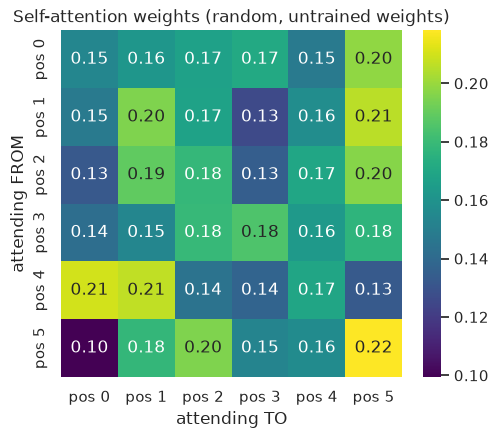

In [3]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(weights[0].detach().numpy(), annot=True, fmt=".2f", cmap="viridis",
            xticklabels=[f"pos {i}" for i in range(seq_len)],
            yticklabels=[f"pos {i}" for i in range(seq_len)])
plt.xlabel("attending TO")
plt.ylabel("attending FROM")
plt.title("Self-attention weights (random, untrained weights)")
plt.show()

With random, untrained weight matrices this heatmap is just noise — but
the mechanism is already doing something an RNN can't: position 0's row
can put weight directly on position 5, in one step, with no need to
"remember" anything across 5 intermediate hidden-state updates. Once
trained (section 5), this same mechanism learns *which* positions are
actually worth attending to for a given task.

## 2. Multi-Head Attention

**Theory.** A single attention "head" can only learn one notion of
relevance at a time. **Multi-head attention** runs several smaller
attention operations in parallel (each with its own Q/K/V projections,
using a fraction of the total model dimension), letting different heads
specialize — one might learn to attend to nearby positions, another to a
specific earlier marker, etc. — then concatenates and projects their
outputs back to the original dimension.

In [4]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        # split d_model into n_heads smaller heads, each attending independently
        Q = self.Wq(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.Wk(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.Wv(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / (self.d_head ** 0.5)
        weights = F.softmax(scores, dim=-1)
        out = weights @ V

        out = out.transpose(1, 2).contiguous().view(B, T, D)  # recombine heads
        return self.Wo(out), weights  # weights shape: (batch, n_heads, seq_len, seq_len)

mha = MultiHeadSelfAttention(d_model=8, n_heads=2)
out, weights = mha(x)
print(f"Output shape: {tuple(out.shape)} (same as input, regardless of n_heads)")
print(f"Per-head attention weight shape: {tuple(weights.shape)}")

Output shape: (1, 6, 8) (same as input, regardless of n_heads)
Per-head attention weight shape: (1, 2, 6, 6)


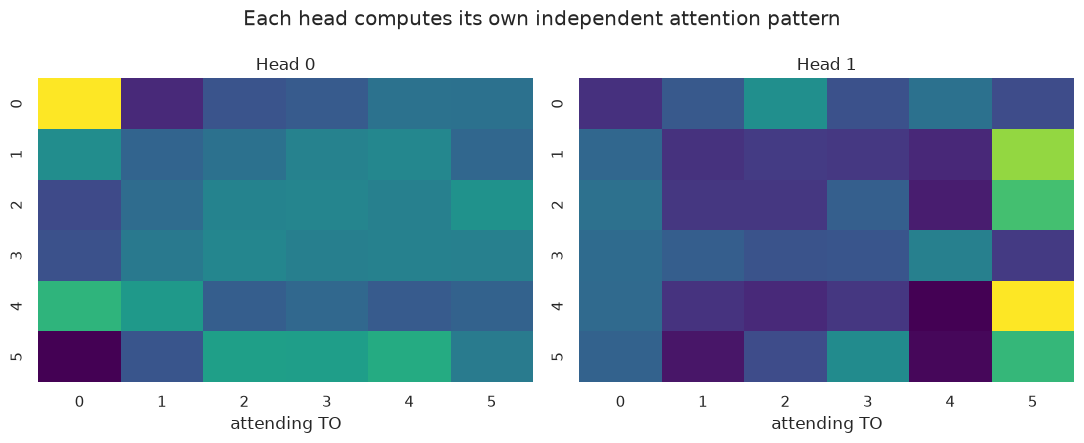

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for h in range(2):
    sns.heatmap(weights[0, h].detach().numpy(), cmap="viridis", ax=axes[h], cbar=False,
                xticklabels=range(seq_len), yticklabels=range(seq_len))
    axes[h].set_title(f"Head {h}")
    axes[h].set_xlabel("attending TO")
plt.suptitle("Each head computes its own independent attention pattern")
plt.tight_layout()
plt.show()

## 3. Positional Encoding

**Theory.** Self-attention treats its input as an unordered *set* — swap
two positions and, without extra information, the attention computation
gives the same result just relabeled. **Positional encoding** injects order
information by adding a position-dependent vector to each input embedding
before attention runs. The original Transformer paper's version uses
sine/cosine waves at different frequencies per dimension, giving every
position a unique, smoothly-varying signature.

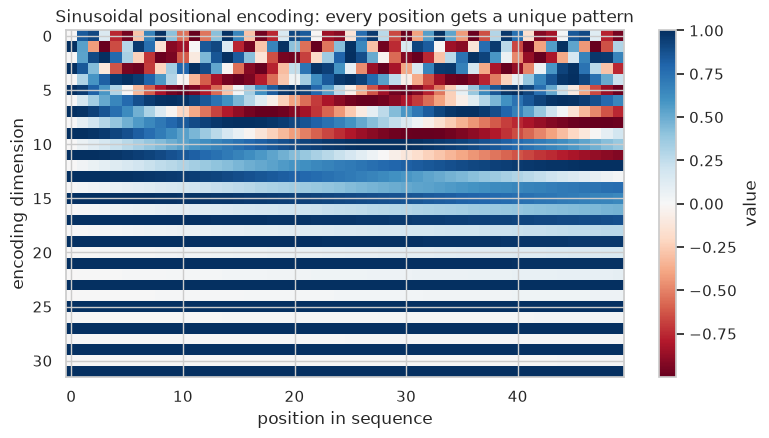

In [6]:
def sinusoidal_positional_encoding(seq_len, d_model):
    position = np.arange(seq_len)[:, None]
    dim = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (dim // 2)) / d_model)
    angles = position * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

pe = sinusoidal_positional_encoding(seq_len=50, d_model=32)

plt.figure(figsize=(9, 4.5))
plt.imshow(pe.T, aspect="auto", cmap="RdBu")
plt.xlabel("position in sequence")
plt.ylabel("encoding dimension")
plt.title("Sinusoidal positional encoding: every position gets a unique pattern")
plt.colorbar(label="value")
plt.show()

Every column (position) is a distinct combination of sine/cosine values —
close positions have similar (but not identical) patterns, giving the
model a smooth notion of "nearby" while every position remains uniquely
identifiable, even far apart. In practice, `nn.TransformerEncoderLayer`
(section 4) doesn't add this automatically — you add it yourself before
the first layer, exactly as done here.

## 4. A Minimal Transformer Encoder Block

**Theory.** A Transformer block wraps multi-head self-attention and a
small feedforward network with two ideas already familiar from earlier
modules:
- **Residual connections** (`12_training_deep_networks` /
  `15_deeper_cnns_transfer_learning`'s ResNet blocks) — the input is added
  back after each sub-layer, so gradients have a direct path through the
  whole stack even as more blocks are added.
- **Layer normalization** — like BatchNorm (`12_training_deep_networks`),
  but normalizes across each *token's* features rather than across the
  batch, which suits variable-length sequences better.

`output = LayerNorm(x + Attention(x))`, then
`output = LayerNorm(output + FeedForward(output))`.

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, _ = self.attn(x)
        x = self.norm1(x + attn_out)     # residual connection + layer norm
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)       # residual connection + layer norm
        return x

block = TransformerBlock(d_model=8, n_heads=2, d_ff=32)
out = block(x)
print(f"TransformerBlock output shape: {tuple(out.shape)} (unchanged from input -- blocks can be stacked)")

TransformerBlock output shape: (1, 6, 8) (unchanged from input -- blocks can be stacked)


## 5. Solving Module 16's Long-Range Dependency Task

Module 16's signal-recall task (remember the sign of position 0, report it
at the last timestep) is exactly the kind of problem attention should
excel at: the answer only ever needs one direct connection, from the last
position back to position 0 — no matter how far apart they are. We use
PyTorch's built-in `nn.TransformerEncoderLayer` here (same math as section
4, production-ready), with the sinusoidal encoding from section 3.

In [8]:
def make_signal_task(n_samples, seq_len, seed):
    task_rng = np.random.default_rng(seed)
    X = task_rng.uniform(-1, 1, size=(n_samples, seq_len, 1)).astype("float32")
    signal = task_rng.choice([-1.0, 1.0], size=n_samples).astype("float32")
    X[:, 0, 0] = signal
    y = (signal > 0).astype("int64")
    return torch.tensor(X), torch.tensor(y)

class TransformerClassifier(nn.Module):
    def __init__(self, d_model=16, n_heads=2, seq_len=150):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        pe = sinusoidal_positional_encoding(seq_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pe, dtype=torch.float32))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=32, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x, return_attention=False):
        x = self.input_proj(x) + self.pos_encoding[:x.size(1)]
        out = self.encoder(x)
        return self.fc(out[:, -1, :])

def train_transformer(seq_len, n_epochs=300, lr=0.001, seed=17):
    torch.manual_seed(seed)
    X_tr, y_tr = make_signal_task(500, seq_len, seed=seed)
    X_te, y_te = make_signal_task(200, seq_len, seed=seed + 1)
    model = TransformerClassifier(seq_len=seq_len)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        acc = (model(X_te).argmax(1) == y_te).float().mean().item()
    return acc, model

In [9]:
seq_lengths = [150, 250, 400]
transformer_accs = []
for L in seq_lengths:
    acc, _ = train_transformer(L)
    transformer_accs.append(acc)
    print(f"seq_len={L}: transformer accuracy = {acc:.3f}")

seq_len=150: transformer accuracy = 1.000


seq_len=250: transformer accuracy = 1.000


seq_len=400: transformer accuracy = 1.000


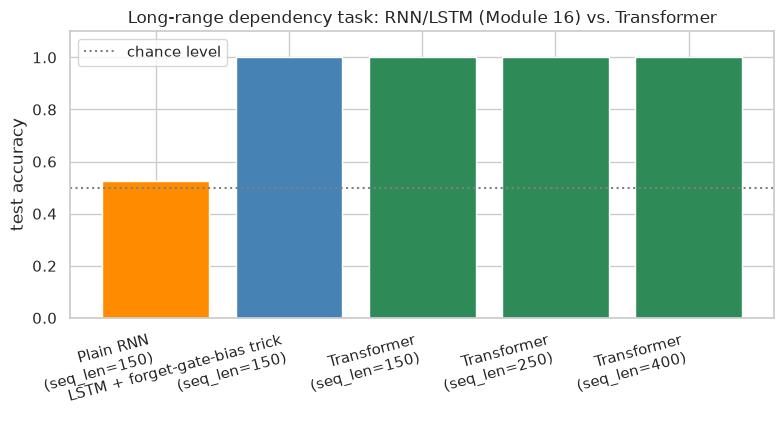

In [10]:
# Module 16's results at seq_len=150, for direct comparison
module16_results = {
    "Plain RNN\n(seq_len=150)": 0.525,
    "LSTM + forget-gate-bias trick\n(seq_len=150)": 1.000,
}

fig, ax = plt.subplots(figsize=(8, 4.5))
bars_x = list(module16_results.keys()) + [f"Transformer\n(seq_len={L})" for L in seq_lengths]
bars_y = list(module16_results.values()) + transformer_accs
colors = ["darkorange", "steelblue"] + ["seagreen"] * len(seq_lengths)
ax.bar(bars_x, bars_y, color=colors)
ax.axhline(0.5, color="gray", linestyle=":", label="chance level")
ax.set_ylabel("test accuracy")
ax.set_title("Long-range dependency task: RNN/LSTM (Module 16) vs. Transformer")
ax.set_ylim(0, 1.1)
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

The transformer solves the task perfectly at every tested length — including
250 and 400, well beyond where the plain RNN failed and without needing any
special initialization trick. This is the concrete payoff of "every
position can attend to every other position directly": the distance
between the signal and where it's needed simply doesn't matter to
attention the way it mattered to a recurrence.

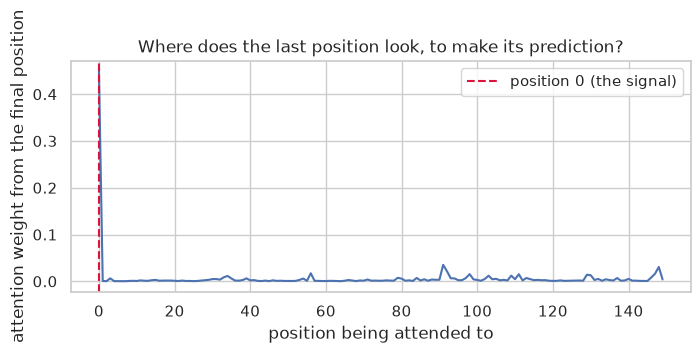

In [11]:
_, trained_model = train_transformer(150)
X_sample, y_sample = make_signal_task(1, 150, seed=99)

trained_model.eval()
with torch.no_grad():
    x_proj = trained_model.input_proj(X_sample) + trained_model.pos_encoding[:150]
    # pull out the attention weights from the underlying self-attention computation
    attn_layer = trained_model.encoder.layers[0].self_attn
    _, attn_weights = attn_layer(x_proj, x_proj, x_proj, need_weights=True, average_attn_weights=True)

plt.figure(figsize=(8, 3))
plt.plot(attn_weights[0, -1, :].numpy())  # attention FROM the last position, TO every position
plt.axvline(0, color="crimson", linestyle="--", label="position 0 (the signal)")
plt.xlabel("position being attended to")
plt.ylabel("attention weight from the final position")
plt.title("Where does the last position look, to make its prediction?")
plt.legend()
plt.show()

If training succeeded at recovering the "obvious" solution, the final
position's attention should spike sharply at position 0 — direct evidence
that the network learned to look exactly where the answer lives, rather
than trying to route that information through 149 intermediate hidden-state
updates the way an RNN would have to.

## Exercises

1. In section 1, apply `SelfAttention` to a sequence where two positions are identical vectors — do they end up with identical rows in the attention weight matrix? Why does that follow from the Q/K/V computation?
2. In section 4, stack two `TransformerBlock`s in sequence (block2(block1(x))) — confirm the output shape is unchanged, then explain why residual connections make this stacking safe even as more blocks are added.
3. In section 5, remove the positional encoding (`self.pos_encoding[:x.size(1)]`) entirely and retrain at `seq_len=150` — does accuracy change? Given position 0 is architecturally special in this task (it's always literally the first element), would you expect positional encoding to matter more on a task where the important position varies?

## Key Takeaways

- Self-attention lets every position directly attend to every other position in one step, avoiding the sequential-propagation bottleneck that caused Module 16's RNN to fail on long sequences.
- Multi-head attention runs several attention computations in parallel, each free to specialize in a different kind of relationship.
- Positional encoding is necessary because attention itself has no built-in sense of order — it treats input as a set unless told otherwise.
- A Transformer block is multi-head attention + a feedforward network, each wrapped in a residual connection and layer norm — the same "make deep stacks trainable" ideas from Modules 12 and 15, applied to a new mechanism.
- On the exact task that broke a plain RNN, an attention-based model succeeds outright, and its attention weights make *why* directly visible — a level of interpretability recurrence doesn't offer as naturally.